# Syncing metrics with phases 

This notebook will be used to update all metrics as per each phases, by creating one dataframe per phase for all trials. 

In [27]:
import pandas as pd
import os

def extract_phase_data(participant_id):
    df = pd.read_pickle(f'{participant_id}/phases_df.pkl')
    trial_rows = []
    
    for idx, row in df.iterrows():
        #print(idx[0])
        phases = row['phases']
        flat_dict = {
            'participant_id': participant_id,
            'trial_number': idx[1],
            'condition':idx[3]
        }
        for phase, (start, end) in phases.items():
            flat_dict[f'{phase.lower().replace(" ", "_")}_start'] = start
            flat_dict[f'{phase.lower().replace(" ", "_")}_end'] = end
        
        trial_rows.append(flat_dict)
    
    return pd.DataFrame(trial_rows)

# Example: for multiple participants
all_phase_data = pd.DataFrame()
patient_dir_data = r"C:\Users\shrinidhi.velan\Documents\Data"
participants = [f for f in os.listdir(patient_dir_data) if os.path.isdir(os.path.join(patient_dir_data, f))]
    

for pid in participants:  # Change 21 to however many participants you have
    try:
        df = extract_phase_data(pid)
        all_phase_data = pd.concat([all_phase_data, df], ignore_index=True)
    except FileNotFoundError:
        print(f'Participant {pid} file not found.')

# Show or save
display(all_phase_data.head())
# all_phase_data.to_csv('phase_timings_all_participants.csv', index=False)

Participant P24 file not found.
Participant P34 file not found.


,participant_id,trial_number,condition,reaching_start,reaching_end,forward_transport_start,forward_transport_end,drinking_start,drinking_end,back_transport_start,back_transport_end,returning_start,returning_end
0,P01,1,unaffected,100.0,214.0,214.0,329.0,329.0,410.0,410.0,593.0,593.0,720
1,P01,2,unaffected,81.0,193.0,193.0,292.0,292.0,366.0,366.0,505.0,505.0,639
2,P01,3,unaffected,99.0,203.0,203.0,300.0,300.0,467.0,467.0,593.0,593.0,716
3,P01,4,unaffected,87.0,188.0,188.0,293.0,293.0,480.0,480.0,609.0,609.0,747
4,P01,5,unaffected,75.0,184.0,184.0,294.0,294.0,467.0,467.0,583.0,583.0,711


In [ ]:
import pandas as pd
appended_data = pd.read_csv('raw_appended_data.csv')
all_phase_data.to_csv('raw_phase_data.csv')

In [ ]:
import pandas as pd
import numpy as np
from tqdm import tqdm

# Step 1: Merge to get phase boundaries per frame
merged = appended_data.merge(all_phase_data, on=['participant_id', 'trial_number'], how='left')

# Helper function to check if the current frame is within the phase boundaries
def in_phase(row, phase):
    # Retrieve the phase boundaries and the current frame
    start = row.get(f"{phase}_start")
    end = row.get(f"{phase}_end")
    frame = row.get("frame_number")
    
    # Convert numpy arrays to scalars if needed and handle empty arrays.
    if isinstance(start, np.ndarray):
        if start.size == 0:
            return False  # no valid boundary value
        elif start.size == 1:
            start = start.item()
        else:
            start = float(start[0])
            
    if isinstance(end, np.ndarray):
        if end.size == 0:
            return False  # no valid boundary value
        elif end.size == 1:
            end = end.item()
        else:
            end = float(end[0])
    
    # Check if boundaries exist or are valid numbers. If not, return False.
    if pd.isna(start) or pd.isna(end):
        return False
    
    # Return True if the frame falls within the phase boundaries.
    return frame >= start and frame < end



# Define the list of phases to extract.
phases = ['reaching', 'forward_transport', 'drinking', 'back_transport', 'returning']

phase_dfs = []

for phase in phases:
    # Build the boolean mask using a list comprehension wrapped with tqdm for a progress bar.
    mask = pd.Series(
        [in_phase(row, phase) for _, row in tqdm(merged.iterrows(),
                                                  total=len(merged),
                                                  desc=f"Processing {phase}")],
        index=merged.index
    )
    
    # Filter the DataFrame rows where the mask is True and add a new column specifying the phase.
    phase_df = merged[mask].copy()
    phase_df['phase'] = phase
    
    phase_dfs.append(phase_df)

# Concatenate all phase-specific DataFrames into one final DataFrame.
all_phases_df = pd.concat(phase_dfs, ignore_index=True)

# Display the resulting DataFrame for verification.
print(all_phases_df.head())


  participant_id  trial_number side condition_x  validity  hand_velocity  \
0            P01             1    R  unaffected         1      15.154540   
1            P01             1    R  unaffected         1      23.262827   
2            P01             1    R  unaffected         1      41.680081   
3            P01             1    R  unaffected         1      77.698223   
4            P01             1    R  unaffected         1     102.839853   

   hand_acceleration  trunk_displacement  elbow_angle  pure_shoulder_angle  \
0                0.0           -2.149292    89.274358            23.204440   
1                0.0           -2.167664    89.448183            23.283908   
2                0.0           -2.240845    89.608271            23.401892   
3                0.0           -2.292297    89.711222            23.620092   
4                0.0           -2.292603    89.739259            23.880001   

   ...  reaching_end  forward_transport_start  forward_transport_end  \
0 

In [ ]:
all_phases_df = all_phases_df.drop(columns = ['condition_x'])

In [57]:
all_phases_df.to_csv('complete_dataframe_with_phases.csv')

In [70]:
all_phases_df.rename(columns={'condition_y': 'condition'}, inplace=True)


In [71]:
all_phases_df

,participant_id,trial_number,side,condition,validity,hand_velocity,hand_acceleration,trunk_displacement,elbow_angle,pure_shoulder_angle,...,reaching_end,forward_transport_start,forward_transport_end,drinking_start,drinking_end,back_transport_start,back_transport_end,returning_start,returning_end,phase
0,P01,1,R,unaffected,1,15.154540,0.0,-2.149292,89.274358,23.204440,...,214.0,214.0,329.0,329.0,410.0,410.0,593.0,593.0,720,reaching
1,P01,1,R,unaffected,1,23.262827,0.0,-2.167664,89.448183,23.283908,...,214.0,214.0,329.0,329.0,410.0,410.0,593.0,593.0,720,reaching
2,P01,1,R,unaffected,1,41.680081,0.0,-2.240845,89.608271,23.401892,...,214.0,214.0,329.0,329.0,410.0,410.0,593.0,593.0,720,reaching
3,P01,1,R,unaffected,1,77.698223,0.0,-2.292297,89.711222,23.620092,...,214.0,214.0,329.0,329.0,410.0,410.0,593.0,593.0,720,reaching
4,P01,1,R,unaffected,1,102.839853,0.0,-2.292603,89.739259,23.880001,...,214.0,214.0,329.0,329.0,410.0,410.0,593.0,593.0,720,reaching
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
1398163,P31,80,L,affected,1,11.275764,0.0,-0.617371,104.264340,31.545468,...,352.0,352.0,534.0,534.0,793,793.0,944.0,944.0,1211,returning
1398164,P31,80,L,affected,1,15.783511,0.0,-0.500061,104.271513,31.530097,...,352.0,352.0,534.0,534.0,793,793.0,944.0,944.0,1211,returning
1398165,P31,80,L,affected,1,16.548761,0.0,-0.408630,104.259847,31.530677,...,352.0,352.0,534.0,534.0,793,793.0,944.0,944.0,1211,returning
1398166,P31,80,L,affected,1,18.635998,0.0,-0.305359,104.222724,31.490456,...,352.0,352.0,534.0,534.0,793,793.0,944.0,944.0,1211,returning


# Let's visualize 

## 1) Overall visualization

In [62]:
# Group by participant, trial, and phase to compute the duration in frames
phase_summary = (
    all_phases_df
    .groupby(['participant_id', 'trial_number', 'phase'])['frame_number']
    .count()
    .reset_index()
    .rename(columns={'frame_number': 'duration'})
)
print(phase_summary.head())


  participant_id  trial_number              phase  duration
0            P01             1     back_transport       183
1            P01             1           drinking        81
2            P01             1  forward_transport       115
3            P01             1           reaching       114
4            P01             1          returning       127


In [64]:
phase_stats = phase_summary.groupby('phase').agg(
    mean_duration = ('duration', 'mean'),
    median_duration = ('duration', 'median'),
    std_duration = ('duration', 'std'),
    min_duration = ('duration', 'min'),
    max_duration = ('duration', 'max')
).reset_index()

display(phase_stats)


,phase,mean_duration,median_duration,std_duration,min_duration,max_duration
0,back_transport,123.520092,117.0,33.421943,1,281
1,drinking,190.719408,177.0,78.656141,1,760
2,forward_transport,138.096187,115.0,85.140901,53,1320
3,reaching,144.010808,130.0,58.469460,1,685
4,returning,200.396130,175.0,107.498266,49,1516


## 2) Visualization across different conditions

In [72]:
# Compute duration of each phase for each trial and condition
phase_summary = (
    all_phases_df
    .groupby(['participant_id', 'trial_number', 'phase', 'condition'])['frame_number']
    .count()
    .reset_index()
    .rename(columns={'frame_number': 'duration'})
)


In [73]:
# Descriptive stats per phase and condition
phase_stats = (
    phase_summary
    .groupby(['phase', 'condition'])
    .agg(
        mean_duration=('duration', 'mean'),
        median_duration=('duration', 'median'),
        std_duration=('duration', 'std'),
        min_duration=('duration', 'min'),
        max_duration=('duration', 'max'),
        count=('duration', 'count')
    )
    .reset_index()
)

display(phase_stats)

,phase,condition,mean_duration,median_duration,std_duration,min_duration,max_duration,count
0,back_transport,affected,128.947132,121.0,39.012537,1,281,889
1,back_transport,unaffected,117.864009,114.0,25.169711,1,250,853
2,drinking,affected,189.464523,175.0,87.983706,1,749,902
3,drinking,unaffected,192.043275,178.0,67.459081,73,760,855
4,forward_transport,affected,162.264967,126.0,110.074658,53,1320,902
5,forward_transport,unaffected,112.598830,105.0,29.228154,57,345,855
6,reaching,affected,158.205980,142.0,65.549254,50,685,903
7,reaching,unaffected,129.018713,116.0,45.356507,1,551,855
8,returning,affected,220.032151,190.0,116.230778,49,1253,902
9,returning,unaffected,179.680702,160.0,93.119775,67,1516,855


In [74]:
pivoted_stats = phase_stats.pivot(index='phase', columns='condition', values='mean_duration')
pivoted_stats.columns.name = None  # Clean up the column name
display(pivoted_stats)


,affected,unaffected
phase,,
back_transport,128.947132,117.864009
drinking,189.464523,192.043275
forward_transport,162.264967,112.598830
reaching,158.205980,129.018713
returning,220.032151,179.680702


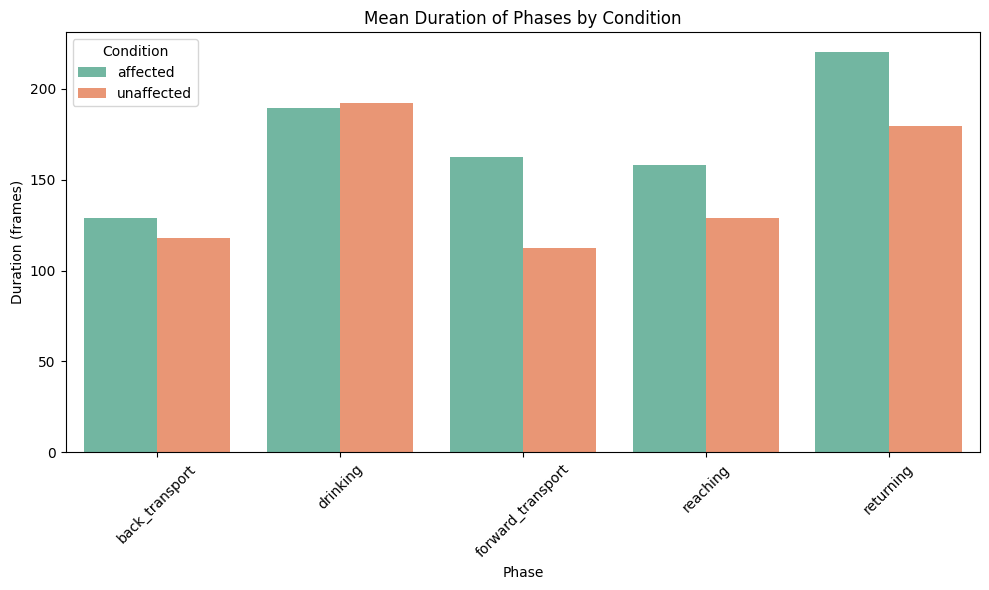

In [75]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))
sns.barplot(
    data=phase_stats,
    x='phase',
    y='mean_duration',
    hue='condition',
    palette='Set2',
    errorbar='sd'
)

plt.title('Mean Duration of Phases by Condition')
plt.ylabel('Duration (frames)')
plt.xlabel('Phase')
plt.xticks(rotation=45)
plt.legend(title='Condition')
plt.tight_layout()
plt.show()


In [77]:
# Pivot to get separate columns for affected/unaffected durations
paired = (
    phase_summary
    .pivot_table(index=['participant_id', 'phase'], columns='condition', values='duration')
    .reset_index()
)

# Add a difference column (unaffected - affected)
paired['diff'] = paired['unaffected'] - paired['affected']

display(paired.head())


condition,participant_id,phase,affected,unaffected,diff
0,P01,back_transport,105.675,113.275,7.600
1,P01,drinking,94.450,134.250,39.800
2,P01,forward_transport,115.600,103.825,-11.775
3,P01,reaching,145.425,92.900,-52.525
4,P01,returning,191.725,129.625,-62.100


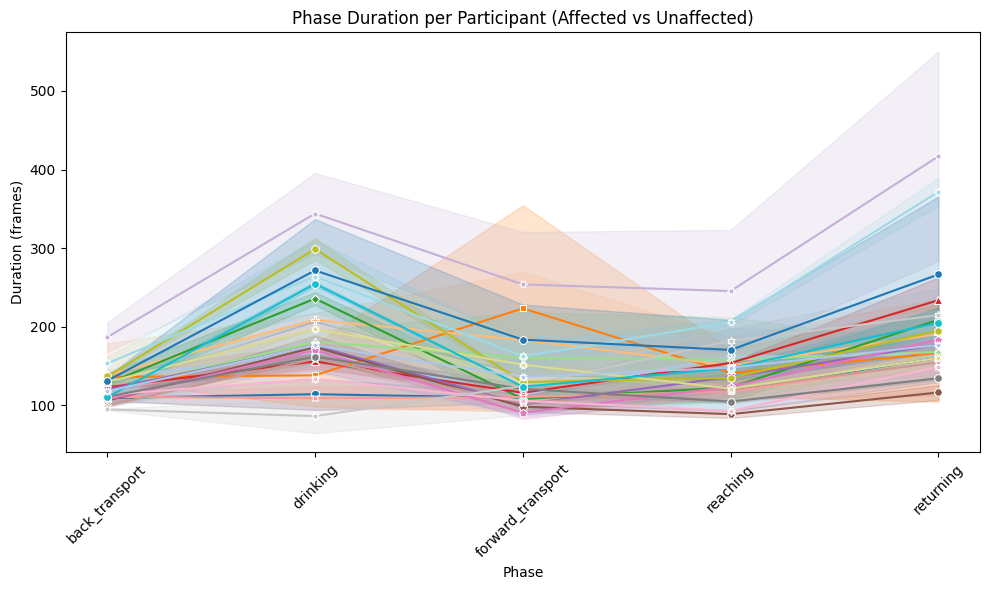

In [80]:
plt.figure(figsize=(10, 6))
sns.lineplot(
    data=paired.melt(id_vars=['participant_id', 'phase'], value_vars=['affected', 'unaffected'],
                     var_name='condition', value_name='duration'),
    x='phase',
    y='duration',
    hue='participant_id',
    style='participant_id',
    markers=True,
    dashes=False,
    legend=False,
    palette='tab20'
)

plt.title('Phase Duration per Participant (Affected vs Unaffected)')
plt.ylabel('Duration (frames)')
plt.xlabel('Phase')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()
